<a href="https://colab.research.google.com/github/aniray2908/Blockchain-Project/blob/main/00_pytorch_warmup/demos/03_linear_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **What We're Building**
A model that learns the relationship y = 2x + 1 purely from noisy data — without being told the formula. By the end, it should figure out that the weight is ~2 and the bias is ~1 all on its own.

#### **Step 1 — Generate the Data**

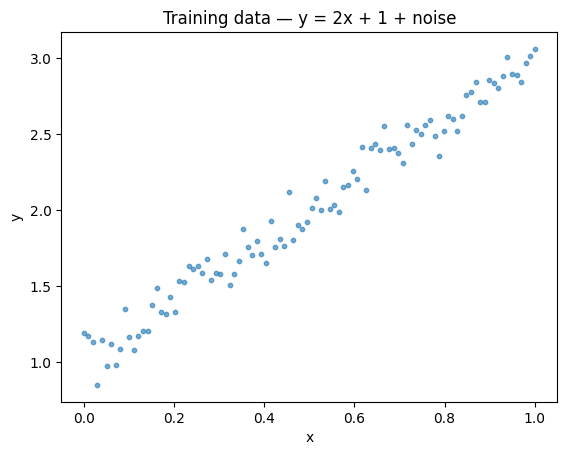

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)   # for reproducibility

# True relationship: y = 2x + 1
X = torch.linspace(0, 1, 100).unsqueeze(1)   # shape (100, 1)
y = 2 * X + 1 + 0.1 * torch.randn(100, 1)   # add a little noise

# Visualise
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.6)
plt.title("Training data — y = 2x + 1 + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### **Step 2 — Define the Model from Scratch**

In [2]:
# Initialise parameters randomly
w = torch.randn(1, requires_grad=True)   # weight — starts random
b = torch.zeros(1, requires_grad=True)  # bias — starts at 0

print(f"Initial weight: {w.item():.4f}")
print(f"Initial bias:   {b.item():.4f}")

Initial weight: -0.5672
Initial bias:   0.0000


#### **Step 3 — Define Loss and Training Loop**

In [3]:
learning_rate = 0.1
epochs = 200
losses = []

for epoch in range(epochs):

    # 1. Forward pass — make predictions
    y_pred = w * X + b                         # y = wx + b

    # 2. Compute loss — mean squared error by hand
    loss = ((y_pred - y) ** 2).mean()
    losses.append(loss.item())

    # 3. Backward pass — compute gradients
    loss.backward()

    # 4. Update weights manually — gradient descent step
    with torch.no_grad():                      # don't track these updates
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # 5. Zero gradients
    w.grad.zero_()
    b.grad.zero_()

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | w: {w.item():.4f} | b: {b.item():.4f}")

print(f"\nFinal weight: {w.item():.4f}  (target: 2.0)")
print(f"Final bias:   {b.item():.4f}  (target: 1.0)")

Epoch   0 | Loss: 5.8095 | w: -0.2947 | b: 0.4579
Epoch  40 | Loss: 0.0818 | w: 1.0916 | b: 1.4926
Epoch  80 | Loss: 0.0342 | w: 1.4682 | b: 1.2908
Epoch 120 | Loss: 0.0180 | w: 1.6877 | b: 1.1732
Epoch 160 | Loss: 0.0125 | w: 1.8155 | b: 1.1046

Final weight: 1.8886  (target: 2.0)
Final bias:   1.0655  (target: 1.0)


#### **Step 4 — Visualise the Results**

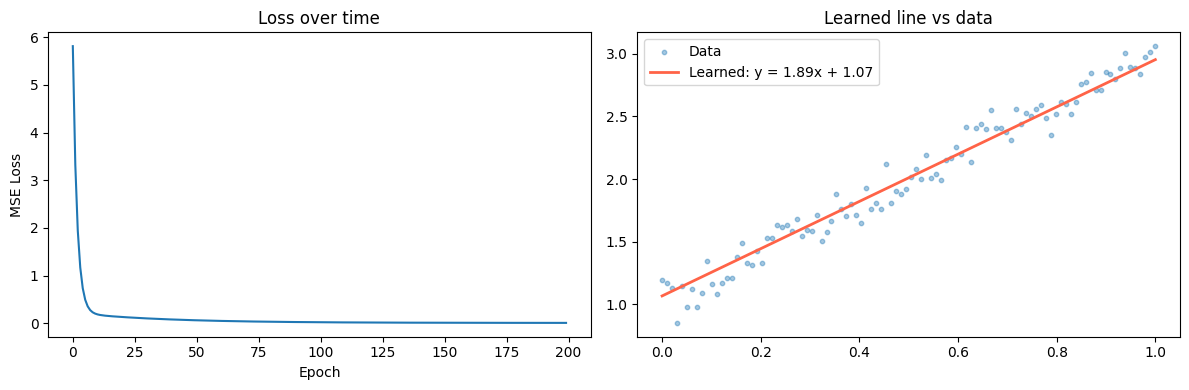

In [4]:
# Plot loss curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

# Plot learned line vs data
plt.subplot(1, 2, 2)
with torch.no_grad():
    y_learned = w * X + b

plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.4, label="Data")
plt.plot(X.numpy(), y_learned.numpy(), color='tomato', linewidth=2, label=f"Learned: y = {w.item():.2f}x + {b.item():.2f}")
plt.title("Learned line vs data")
plt.legend()

plt.tight_layout()
plt.show()

#### **Step 5 — Upgrade: Use nn.Linear and optim**

In [5]:
import torch.nn as nn

# Model
model     = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn   = nn.MSELoss()

losses_v2 = []

for epoch in range(200):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    losses_v2.append(loss.item())

    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\nLearned weight: {model.weight.item():.4f}  (target: 2.0)")
print(f"Learned bias:   {model.bias.item():.4f}  (target: 1.0)")

Epoch   0 | Loss: 5.9954
Epoch  40 | Loss: 0.0373
Epoch  80 | Loss: 0.0190
Epoch 120 | Loss: 0.0128
Epoch 160 | Loss: 0.0107

Learned weight: 1.9288  (target: 2.0)
Learned bias:   1.0439  (target: 1.0)


#### **Step 6 — Compare Both Loss Curves**

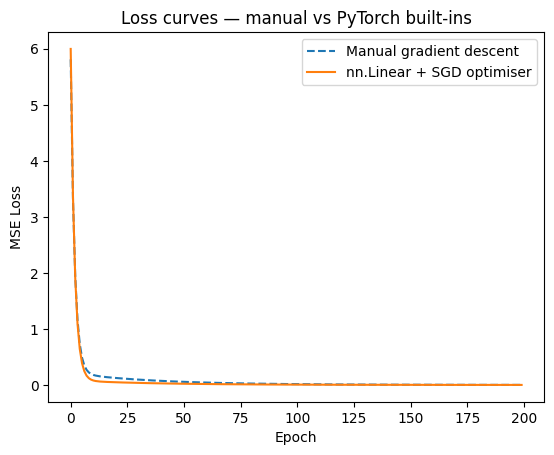

In [6]:
plt.plot(losses,    label='Manual gradient descent', linestyle='--')
plt.plot(losses_v2, label='nn.Linear + SGD optimiser')
plt.title("Loss curves — manual vs PyTorch built-ins")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()